# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [8]:
# Diferencias
print("LabelEncoder: Asigna números enteros (0, 1, 2...)")
print(f"Sex original: {data['sex'].unique()}")
print(f"Sex codificado: {data['sex_label'].unique()}")
print("\nOneHotEncoder: Crea columnas binarias (0/1)")
print("Embarked codificado (primeras filas):")
print(onehot_encoder.head())

LabelEncoder: Asigna números enteros (0, 1, 2...)
Sex original: <StringArray>
['male', 'female']
Length: 2, dtype: str
Sex codificado: [1 0]

OneHotEncoder: Crea columnas binarias (0/1)
Embarked codificado (primeras filas):
   embarked_C  embarked_Q  embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

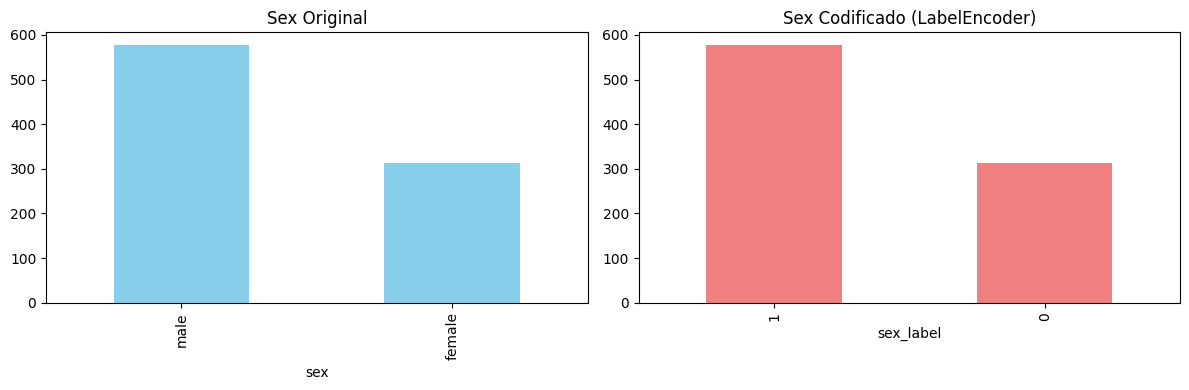

In [9]:
# Gráfica de barras
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data['sex'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Sex Original')
data['sex_label'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Sex Codificado (LabelEncoder)')
plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [10]:
# OneHotEncoder para 'class'
class_encoded = pd.get_dummies(data['class'], prefix='class')
print("OneHotEncoder para 'class':")
print(class_encoded.head())
print("\nVentajas: Evita orden implícito, mejor para modelos ML que no asumen jerarquía")

OneHotEncoder para 'class':
   class_First  class_Second  class_Third
0        False         False         True
1         True         False        False
2        False         False         True
3         True         False        False
4        False         False         True

Ventajas: Evita orden implícito, mejor para modelos ML que no asumen jerarquía


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [11]:
# Recomendación
print("Para modelos ML: OneHotEncoder es preferible porque:")
print("1. Evita introducir orden artificial en variables categóricas")
print("2. Funciona mejor con algoritmos como Regresión Logística, SVM, etc.")
print("3. LabelEncoder solo es útil para árboles de decisión")
print(f"\nEjemplo: 'class' tiene {data['class'].nunique()} categorías")
print("OneHotEncoder crearía 3 columnas binarias (sin multicolinealidad)")

Para modelos ML: OneHotEncoder es preferible porque:
1. Evita introducir orden artificial en variables categóricas
2. Funciona mejor con algoritmos como Regresión Logística, SVM, etc.
3. LabelEncoder solo es útil para árboles de decisión

Ejemplo: 'class' tiene 3 categorías
OneHotEncoder crearía 3 columnas binarias (sin multicolinealidad)
